In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv('titanic_toy.csv')

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [6]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [7]:
df.shape

(891, 4)

In [8]:
X_train,X_test,Y_train,Y_test=train_test_split(df.drop(columns=['Survived']),
                                                               df['Survived'],
                                                               test_size=0.2,
                                                               random_state=42)

In [12]:
X_train['Age_99']=X_train['Age'].fillna(99)
X_train['Age_minus1']=X_train['Age'].fillna(-1)


X_train['fare_999']=X_train['Fare'].fillna(999)
X_train['fare_minus1']=X_train['Fare'].fillna(-1)

### ***Check the Varinace***

In [14]:
print('orignal age varibale variance:',X_train['Age'].var())
print('Age Varance after 99 imputation:',X_train['Age_99'].var())
print('Age Varance after minus1 imputation:',X_train['Age_minus1'].var())


print('orignal fare varibale variance:',X_train['Fare'].var())
print('Fare Varance after 999 imputation:',X_train['fare_999'].var())
print('fare Varance after minus1 imputation:',X_train['fare_minus1'].var())

orignal age varibale variance: 210.2517072477438
Age Varance after 99 imputation: 932.9665366701436
Age Varance after minus1 imputation: 315.99550362600644
orignal fare varibale variance: 2761.031434948639
Fare Varance after 999 imputation: 47525.47059536007
fare Varance after minus1 imputation: 2675.2394049177087


### ***Now check the Distribution***

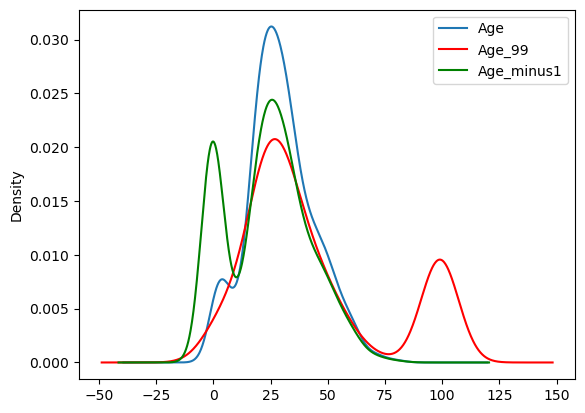

In [15]:
fig=plt.figure()
ax=fig.add_subplot(111)
# orignal variable distribution
X_train['Age'].plot(kind='kde',ax=ax)
# afer median
X_train['Age_99'].plot(kind='kde',ax=ax,color='red')
# after mean
X_train['Age_minus1'].plot(kind='kde',ax=ax,color='green')

#add legends
lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

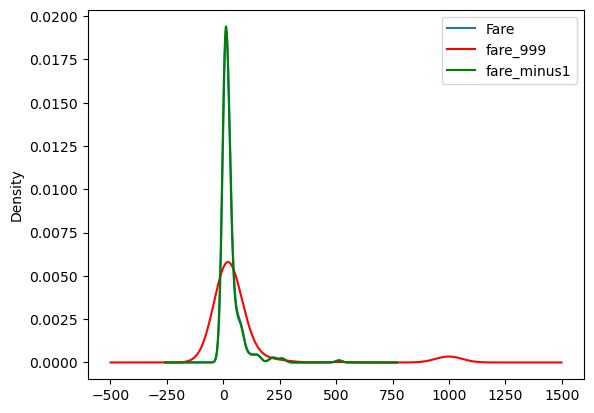

In [16]:
fig=plt.figure()
ax=fig.add_subplot(111)
# orignal variable distribution
X_train['Fare'].plot(kind='kde',ax=ax)
# afer median
X_train['fare_999'].plot(kind='kde',ax=ax,color='red')
# after mean
X_train['fare_minus1'].plot(kind='kde',ax=ax,color='green')

#add legends
lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

### ***Now check the Covariance***

In [17]:
X_train.cov()

,Age,Fare,Family,Age_999,Age_minus1,fare_999,fare_minus1,Age_99
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,130.495777,69.137162,210.251707
Fare,75.481375,2761.031435,18.599163,-111.965046,135.785804,2761.031435,2761.031435,-111.965046
Family,-6.993325,18.599163,2.830892,-6.941982,-5.034556,16.878492,17.684447,-6.941982
Age_999,210.251707,-111.965046,-6.941982,932.966537,-166.460682,-255.051165,-101.137070,932.966537
Age_minus1,210.251707,135.785804,-5.034556,-166.460682,315.995504,262.712284,124.270305,-166.460682
fare_999,130.495777,2761.031435,16.878492,-255.051165,262.712284,47525.470595,1063.944817,-255.051165
fare_minus1,69.137162,2761.031435,17.684447,-101.137070,124.270305,1063.944817,2675.239405,-101.137070
Age_99,210.251707,-111.965046,-6.941982,932.966537,-166.460682,-255.051165,-101.137070,932.966537


In [20]:
X_train.corr()

,Age,Fare,Family,Age_999,Age_minus1,fare_999,fare_minus1,Age_99
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.039967,0.085422,1.000000
Fare,0.091482,1.000000,0.207193,-0.069365,0.145071,1.000000,1.000000,-0.069365
Family,-0.319651,0.207193,1.000000,-0.135079,-0.168329,0.046016,0.203212,-0.135079
Age_999,1.000000,-0.069365,-0.135079,1.000000,-0.306576,-0.038303,-0.064017,1.000000
Age_minus1,1.000000,0.145071,-0.168329,-0.306576,1.000000,0.067792,0.135159,-0.306576
fare_999,0.039967,1.000000,0.046016,-0.038303,0.067792,1.000000,0.094357,-0.038303
fare_minus1,0.085422,1.000000,0.203212,-0.064017,0.135159,0.094357,1.000000,-0.064017
Age_99,1.000000,-0.069365,-0.135079,1.000000,-0.306576,-0.038303,-0.064017,1.000000


<Axes: >

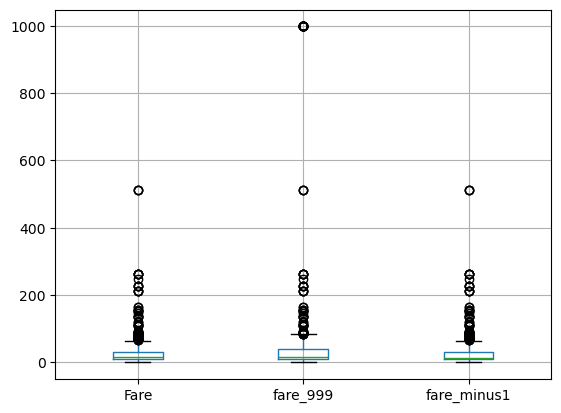

In [23]:
X_train[['Fare','fare_999','fare_minus1']].boxplot()

### ***Using sklean***

In [24]:
X_train,X_test,Y_train,Y_test=train_test_split(df.drop(columns=['Survived']),
                                              df['Survived'],
                                              test_size=0.2,
                                              random_state=42)

In [25]:
imputer1=SimpleImputer(strategy='constant',fill_value=99)
imputer2=SimpleImputer(strategy='constant',fill_value=999)

In [26]:
trf=ColumnTransformer([
                     ('imputer1',imputer1,['Age']),
                     ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [27]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [28]:
ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',SimpleImputer(strategy='constant',fill_value=99),['Age']),
                               ('imputer2',SimpleImputer(strategy='constant',fill_value=999),['Fare'])])

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [29]:
X_train=trf.transform(X_train)
X_test=trf.transform(X_test)

In [30]:
X_train

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    , 999.    ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]], shape=(712, 3))